In [1]:
%load_ext jupyter_black

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from einops import pack, einsum, reduce, rearrange, repeat

# Module definition
- Dataset
- Embedding
- Masked SoftMax
- MultiHeadAttention

In [3]:
class TimeSeriesDataSet(Dataset):
    def __init__(
        self,
        pathfile: str,
        input_size: int = 24,
        var=["time", "P", "T"],
        mean: torch.Tensor | None = None,
        scale: torch.Tensor | None = None,
    ):
        """
        Data loader to infer time series.

        pathfile: path to the dataframe, csv.
        input_size: lenght of the time series used for explicative variables
        output_size: lenght of the time series to infer
        var: dictionnary of column name used for variables X and Y
        for_rnn: if the data loader is used for RNN, return also warmup Y
        """
        self.dataset = pd.read_csv(pathfile)
        self.input_size = input_size
        self.var = var

        if (mean is None) and (scale is None):
            self.mean = torch.from_numpy(self.dataset[self.var].mean().values).to(
                torch.float32
            )
            self.scale = torch.from_numpy(self.dataset[self.var].std().values).to(
                torch.float32
            )
        else:
            self.mean = mean
            self.scale = scale

    def __len__(self) -> int:
        return len(self.dataset) - self.input_size - 1

    def __getitem__(self, idx) -> tuple[torch.Tensor, torch.Tensor]:
        # Get data
        X = torch.from_numpy(
            self.dataset.iloc[idx : (idx + self.input_size)][self.var].values
        ).to(torch.float32)

        # Standardize
        return (X - self.mean) / self.scale

In [4]:
class TimeEmbedding(nn.Module):
    """Module performing time embedding"""

    def __init__(self, time_range: float, time_embedding_dim: int = 64):
        super(TimeEmbedding, self).__init__()
        assert (time_embedding_dim % 2) == 0
        self.time_embedding_dim = time_embedding_dim
        self.frequencies = rearrange(
            torch.arange(1, self.time_embedding_dim // 2 + 1) / time_range, "t -> 1 1 t"
        )

    def forward(self, T: torch.Tensor) -> torch.Tensor:
        """
        T: tensor of size [b t] or [b t 1]
        output: tensor of size [b t e] with e=time_embedding_dim
        """
        # Ensure T is of size [batch_size, n_times, 1]
        assert (T.ndim == 2) | (T.ndim == 3 and T.shape[2] == 1)
        if T.ndim == 2:
            T = T.unsqueeze(-1)

        # Perform embedding
        return pack(
            [
                torch.cos(2 * torch.pi * T * self.frequencies),
                torch.sin(2 * torch.pi * T * self.frequencies),
            ],
            "b t *",
        )[0]

In [5]:
def masked_sotfmax(A: torch.Tensor, M: torch.Tensor, dim=-1) -> torch.Tensor:
    """Compute masked softmax given masked values: M=0 -> missing values
    A: tensor of size [batch, time, feature] or [batch, time, feature, nb_head]
    M: tensor of size [batch, time] or  [batch, time, 1]
    """

    # Check size consistency
    assert M.ndim in (2, 3)
    assert A.shape[0] == M.shape[0]
    assert A.shape[1] == M.shape[1]
    if A.ndim == 2:
        M = M.unsqueeze(1)
    elif A.ndim == 4:
        M = rearrange(M, " b t -> b 1 t 1")

    masked_A = A.masked_fill(torch.logical_not(M), -1e9)
    out = F.softmax(masked_A, dim=dim)
    return out

In [6]:
class MultiAttentionNetwork(nn.Module):
    """Module performing temporal attention for linear prediction"""

    def __init__(
        self,
        input_size: int,
        time_range: float = 1.0,
        nb_attention_heads: int = 1,
        time_embedding_dim: int = 64,
    ):
        super(MultiAttentionNetwork, self).__init__()
        # Init size
        self.input_size = input_size
        self.time_range = time_range
        self.nb_attention_heads = nb_attention_heads
        self.time_embedding_dim = time_embedding_dim
        self.time_embedding = TimeEmbedding(
            self.time_range, self.time_embedding_dim * self.nb_attention_heads
        )

        # Init keys, queries and values layers
        self.K = nn.Linear(
            self.time_embedding_dim * self.nb_attention_heads,
            self.time_embedding_dim * self.nb_attention_heads,
            bias=False,
        )
        self.Q = nn.Linear(
            self.time_embedding_dim * self.nb_attention_heads,
            self.time_embedding_dim * self.nb_attention_heads,
            bias=False,
        )
        nn.init.normal_(
            self.K.weight,
            std=np.sqrt(1 / (self.time_embedding_dim * self.nb_attention_heads)),
        )
        nn.init.normal_(
            self.Q.weight,
            std=np.sqrt(1 / (self.time_embedding_dim * self.nb_attention_heads)),
        )

        self.V = nn.Linear(input_size, input_size * self.nb_attention_heads, bias=False)
        self.W = nn.Linear(self.nb_attention_heads * input_size, input_size)

    def forward(
        self,
        X: torch.Tensor,
        T: torch.Tensor,
        Tp: torch.Tensor,
        M: torch.Tensor | None = None,
    ) -> torch.Tensor:
        """
        X: tensor of size [batch_size, temporal_sequence, features]
        T: tensor of size [batch_size, temporal_sequence, 1]
        Tp: tensor of size [batch_size, temporal_sequence_p, 1] -> sequence to be predicted
        """
        assert X.shape[0] == T.shape[0]
        assert X.shape[1] == T.shape[1]
        assert X.shape[0] == Tp.shape[0]

        # Time embedding
        Te = self.time_embedding(T)
        Tpe = self.time_embedding(Tp)

        # Compute Keys, Querys and Values
        temporal_keys = rearrange(
            self.K(Te),
            "b t (e a) -> b t e a",
            a=self.nb_attention_heads,
            e=self.time_embedding_dim,
        )
        temporal_queries = rearrange(
            self.Q(Tpe),
            "b t (e a) -> b t e a",
            a=self.nb_attention_heads,
            e=self.time_embedding_dim,
        )
        values = rearrange(
            self.V(X),
            "b t (f a) -> b t f a",
            a=self.nb_attention_heads,
            f=self.input_size,
        )

        # Scaled dot product - einsum is used instead of bmm(Q, K.T)
        temporal_attention = einsum(
            temporal_queries, temporal_keys, "b t e a, b u e a-> b t u a"
        ) * temporal_keys.shape[2] ** (-0.5)

        # Compute masked attention along axis "u"
        if M is not None:
            temporal_attention = masked_sotfmax(temporal_attention, M, dim=2)
        else:
            temporal_attention = F.softmax(temporal_attention, 2)

        # Inference
        out = self.W(
            rearrange(
                einsum(temporal_attention, values, "b u v a,  b v f a-> b u f a"),
                "b u f a->b u (f a)",
            )
        )

        return out, temporal_attention

# Simulation
- Init data set
- Define function to mask randomly time

In [7]:
batch_size = 2048
input_size = 24 * 3
# Init train data loader
train_data = TimeSeriesDataSet(
    "../../Data/time_series/data/meteo_train.csv",
    input_size=input_size,
)
train_data_loader = DataLoader(
    train_data, batch_size=batch_size, shuffle=True, num_workers=8
)

# Init test data loader
test_data = TimeSeriesDataSet(
    "../../Data/time_series/data/meteo_test.csv",
    input_size=input_size,
    mean=train_data.mean,
    scale=train_data.scale,
)
test_data_loader = DataLoader(test_data, batch_size=batch_size, num_workers=8)

# Init valid data loader
valid_data = TimeSeriesDataSet(
    "../../Data/time_series/data/meteo_valid.csv",
    input_size=input_size,
    mean=train_data.mean,
    scale=train_data.scale,
)
valid_data_loader = DataLoader(
    valid_data, batch_size=batch_size, shuffle=True, num_workers=8
)

In [8]:
def time_masker(
    T: torch.Tensor, n_masked: int = 1, masked_value: float = -10000
) -> torch.Tensor:
    """Generate mask value for batch T

    n_masked: average number of masked values per batch element
    """
    batch_size, n_times, _ = T.shape
    M = torch.full(
        (batch_size * n_times,), fill_value=True, dtype=torch.bool, device=T.device
    )
    idx = torch.randperm(batch_size * n_times, device=M.device)[: batch_size * n_masked]
    M[idx] = False
    M = rearrange(M, "(b t) -> b t", b=batch_size, t=n_times)
    return M

In [9]:
model = MultiAttentionNetwork(
    input_size=2, time_embedding_dim=32, nb_attention_heads=4, time_range=0.0016 * 90
)
# loss_fn = nn.L1Loss()
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)
n_epochs = 15
n_masked = 40

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
model = model.to(device)
valid_loss: list[float] = []
train_loss: list[float] = []

for epoch in range(n_epochs):
    model.train()
    accu = 0.0
    for X in train_data_loader:
        # Reshape data & extract time feature
        T, X = X[..., 0].unsqueeze(-1), X[..., 1:]

        # Add missing value
        M = time_masker(T, n_masked=n_masked)

        # Forward
        out, A = model(X, T, T, M)
        loss = loss_fn(out, X)

        # Backward
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        accu += loss.item()
    train_loss.append(accu / len(train_data_loader))

    model.eval()
    accu = 0.0
    with torch.no_grad():
        for X in valid_data_loader:
            T, X = X[..., 0].unsqueeze(-1), X[..., 1:]
            M = time_masker(T, n_masked=n_masked)
            out, A = model(X, T, T)
            loss = loss_fn(out, X)
            accu += loss.item()
        valid_loss.append(accu / len(valid_data_loader))
    print(f"Train {epoch}: {train_loss[-1]} and Valid {epoch}: {valid_loss[-1]}")

Train 0: 0.7108330142994722 and Valid 0: 2.382741400173732
Train 1: 0.2637426940103372 and Valid 1: 1.4770368933677673
Train 2: 0.0790592556198438 and Valid 2: 1.1991874490465437
Train 3: 0.026893782584617536 and Valid 3: 0.8950076358658927
Train 4: 0.016038644942454994 and Valid 4: 0.6568921506404877
Train 5: 0.01263111608568579 and Valid 5: 0.5914602833134788
Train 6: 0.011058825029370686 and Valid 6: 0.5614444315433502
Train 7: 0.01025634107645601 and Valid 7: 0.5444094112941197
Train 8: 0.009885418539245924 and Valid 8: 0.5258021439824786
Train 9: 0.00953416561242193 and Valid 9: 0.5113321968487331
Train 10: 0.009290197437318662 and Valid 10: 0.5025679511683327
Train 11: 0.00907079545625796 and Valid 11: 0.5003649038927895
Train 12: 0.008835114810305337 and Valid 12: 0.48858710271971567
Train 13: 0.0086559954409798 and Valid 13: 0.4832661237035479
Train 14: 0.008472128848855695 and Valid 14: 0.4856997898646763


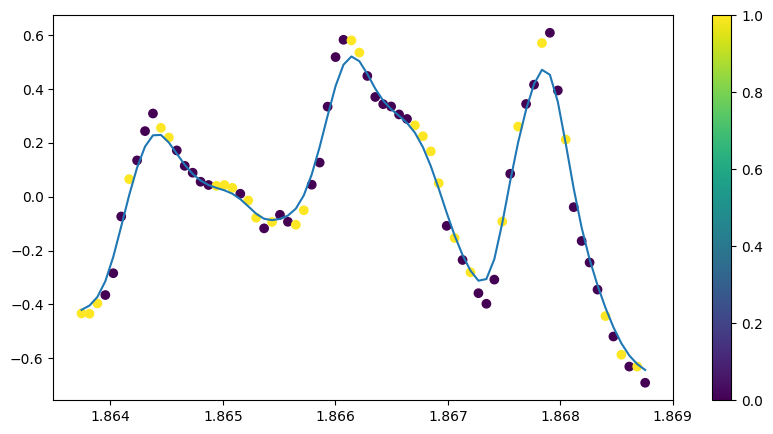

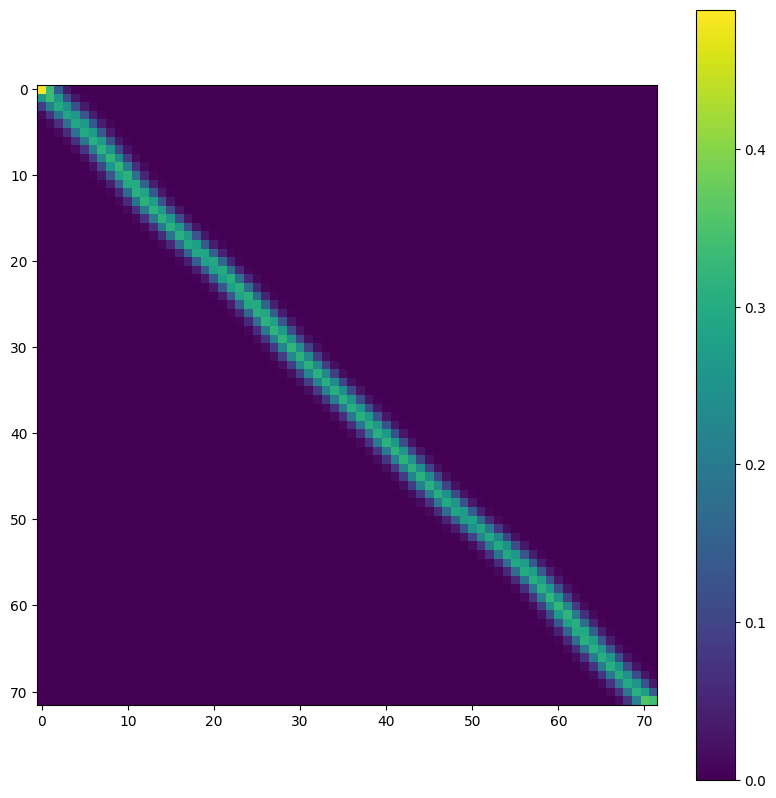

In [10]:
sample = 10
plt.figure(figsize=(10, 5))
plt.scatter(T[sample, :], X[sample, :, 1], c=M[sample, :])
plt.colorbar()
plt.plot(T[sample, :], out[sample, :, 1].detach().numpy())
plt.figure(figsize=(10, 10))
plt.imshow(A[sample, ..., 0].detach().numpy())
plt.colorbar()

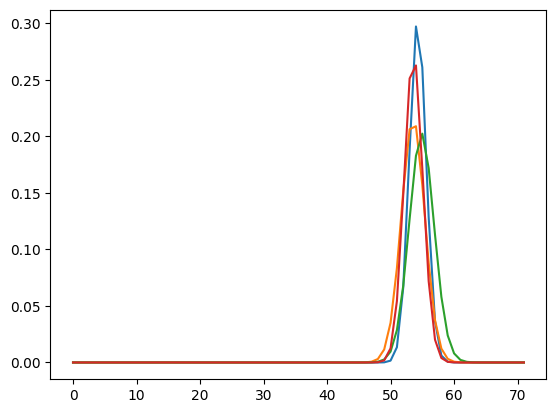

In [11]:
# Plot Attention for one query
for i in range(A.shape[3]):
    plt.plot(A[sample, 54, :, i].detach().numpy())

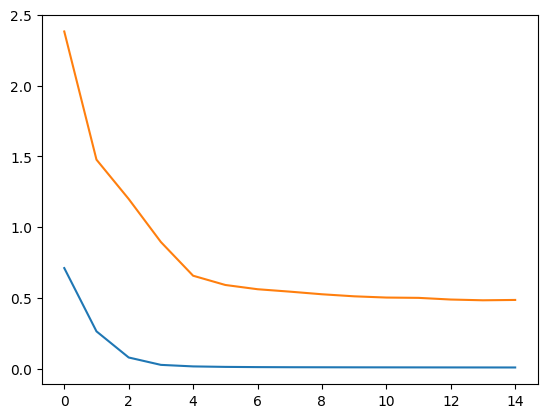

In [12]:
plt.plot(train_loss)
plt.plot(valid_loss)

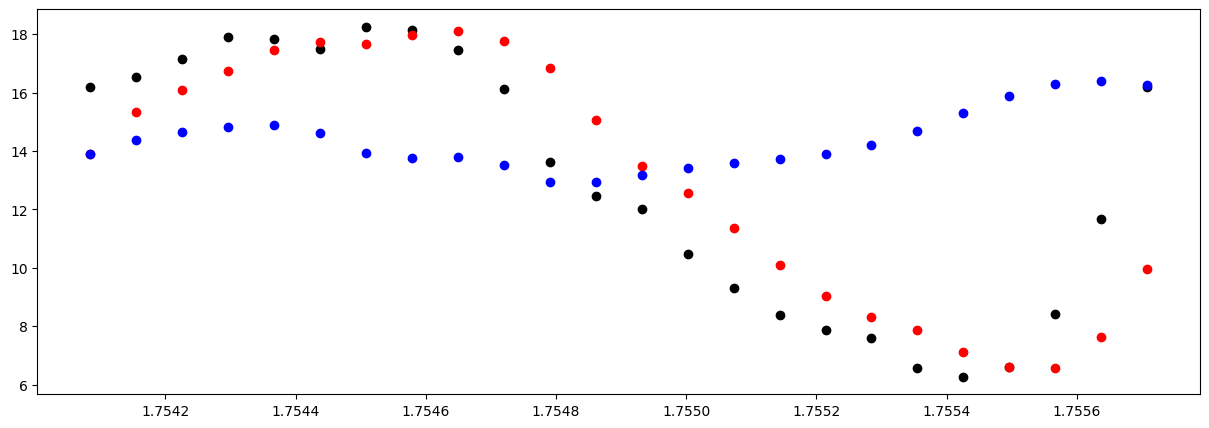

In [13]:
mean, scale = train_data.mean[-1], train_data.scale[-1]
plt.figure(figsize=(15, 5))
start = 24 * 10
TP = []
S = []
for s in range(start, start + 24):
    X = valid_data[s]
    Y = valid_data[s + 1]
    T, X = X[..., 0].unsqueeze(-1), X[..., 1:]
    Tp, Xp = Y[-1, 0].unsqueeze(-1), Y[-1, 1:].unsqueeze(1)
    TP.append(Tp)
    out, A = model(X[None, ...], T[None, ...], Tp[None, ...])
    plt.scatter(Tp, Xp[1] * scale + mean, color="k")
    plt.scatter(Tp, (out[0, 0, 1] * scale + mean).detach().numpy(), color="r")

# Sequence prediction
X = valid_data[start]
T, X = X[..., 0].unsqueeze(-1), X[..., 1:]
TP = torch.cat((TP))
out, A = model(X[None, ...], T[None, ...], TP[None, ...])
plt.scatter(TP, (out[0, :, 1] * scale + mean).detach().numpy(), color="b")

torch.Size([1, 72, 128])


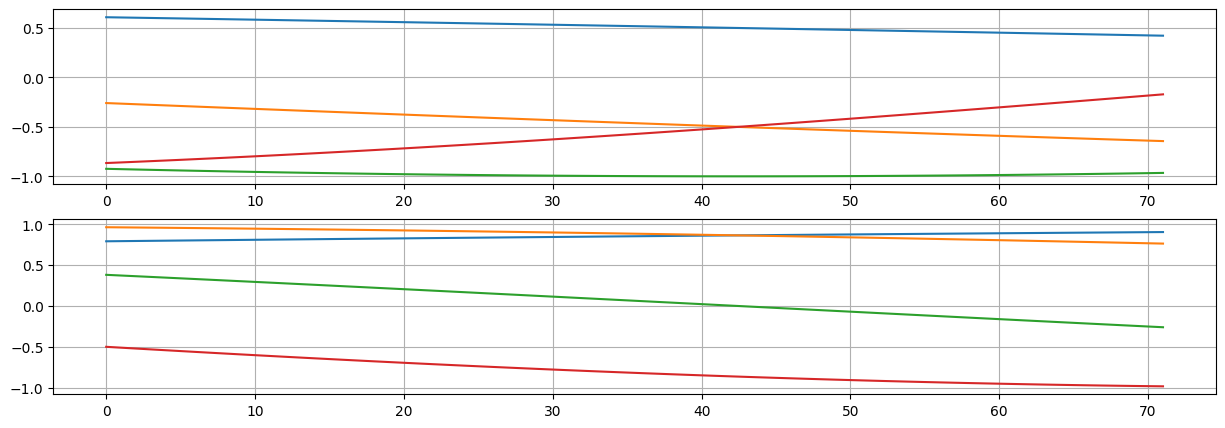

In [14]:
Tp, Xp = Y[-1, 0].unsqueeze(-1), Y[-1, 1:].unsqueeze(1)

E = model.time_embedding(T[None, ...])
print(E.shape)

fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(15, 5))
for i in range(4):
    axs[0].plot(E[0, :, i].detach().numpy())
    axs[1].plot(E[0, :, E.shape[-1] // 2 + i].detach().numpy())
axs[0].grid()
axs[1].grid()